# 🛡️ Online Fraud Detection System — Training Notebook
**Student:** Sakshi &nbsp;|&nbsp; **College:** Gautam Buddha University &nbsp;|&nbsp; **Program:** B.Tech CSE (AI)


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, accuracy_score)
from imblearn.over_sampling import SMOTE

pd.set_option('display.max_columns', 50)

## 1. Load the dataset

In [14]:
df = pd.read_csv('data\creditcard.csv')

print(f"Total Transactions : {len(df)}")
print(f"Legitimate (0)     : {df['Class'].value_counts()[0]}")
print(f"Fraudulent (1)     : {df['Class'].value_counts()[1]}")
print(f"Fraud Percentage   : {round(df['Class'].mean()*100, 3)}%")

df.head()

Total Transactions : 284807
Legitimate (0)     : 284315
Fraudulent (1)     : 492
Fraud Percentage   : 0.173%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory data analysis

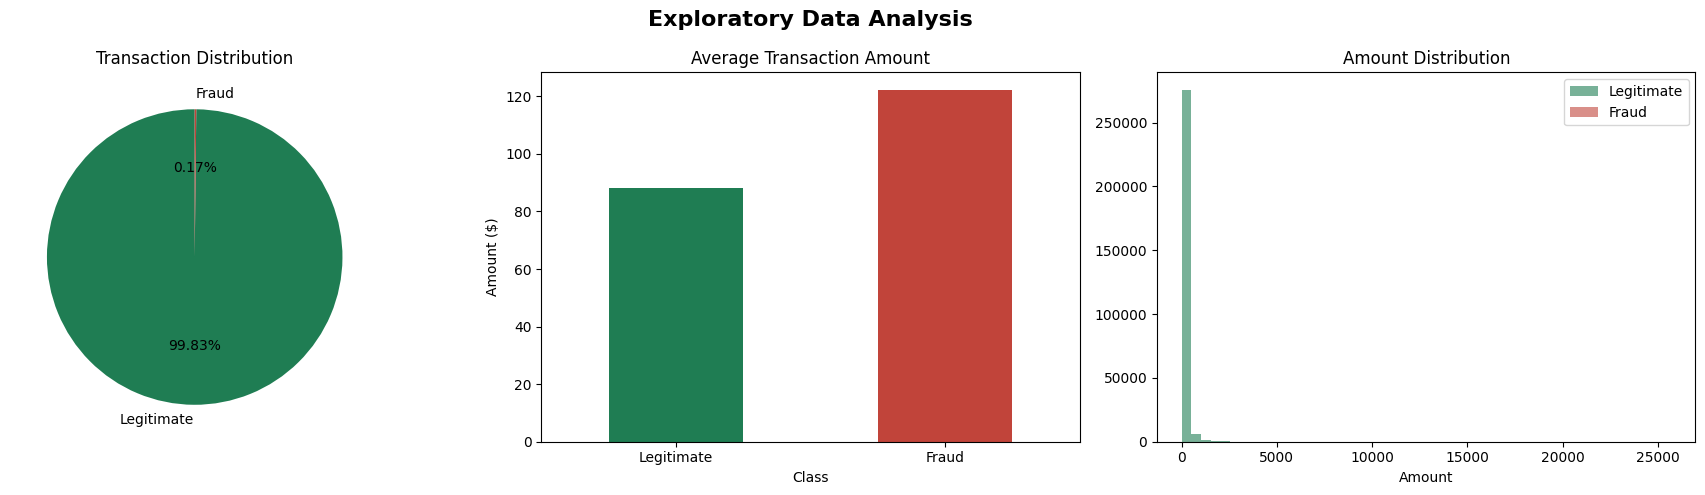

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=16, fontweight='bold')

axes[0].pie(df['Class'].value_counts(), labels=['Legitimate', 'Fraud'], autopct='%1.2f%%',
            colors=['#1F7D53', '#C1443A'], startangle=90)
axes[0].set_title('Transaction Distribution')

df.groupby('Class')['Amount'].mean().plot(kind='bar', ax=axes[1], color=['#1F7D53', '#C1443A'])
axes[1].set_title('Average Transaction Amount')
axes[1].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[1].set_ylabel('Amount ($)')

axes[2].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6, label='Legitimate', color='#1F7D53')
axes[2].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.6, label='Fraud', color='#C1443A')
axes[2].set_title('Amount Distribution')
axes[2].set_xlabel('Amount')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Preprocessing




In [16]:
X = df.drop('Class', axis=1)
y = df['Class']

scaler_time = StandardScaler()
scaler_amount = StandardScaler()
X['Time'] = scaler_time.fit_transform(X[['Time']])
X['Amount'] = scaler_amount.fit_transform(X[['Amount']])

print("Applying SMOTE to handle class imbalance...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print(f"After SMOTE - Total samples: {len(X_resampled)}")

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)
print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Column order     : {list(X_train.columns)}")

Applying SMOTE to handle class imbalance...
After SMOTE - Total samples: 568630
Training samples : 454904
Testing samples  : 113726
Column order     : ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## 4. Train all models

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

results = {}
for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_prob': y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob)
    }
    print(f"Done! Accuracy: {round(results[name]['accuracy']*100, 2)}%")

Training Logistic Regression... Done! Accuracy: 94.84%
Training Decision Tree... Done! Accuracy: 99.83%
Training Random Forest... Done! Accuracy: 99.99%
Training KNN... Done! Accuracy: 99.9%


## 5. Compare models

In [18]:
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [round(v['accuracy']*100, 2) for v in results.values()],
    'ROC-AUC': [round(v['roc_auc'], 4) for v in results.values()]
}).sort_values('ROC-AUC', ascending=False)

comparison_df

,Model,Accuracy,ROC-AUC
2,Random Forest,99.99,1.0000
3,KNN,99.90,0.9997
1,Decision Tree,99.83,0.9983
0,Logistic Regression,94.84,0.9895


## 6. Best model -- detailed evaluation

Best Model: Random Forest

              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



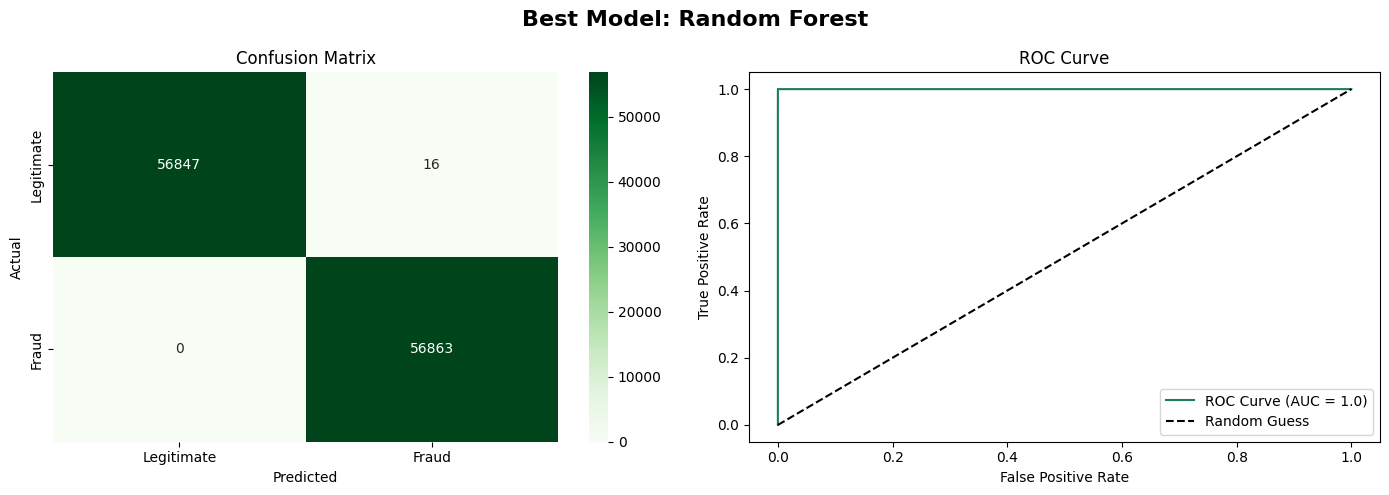

In [19]:
best_model_name = comparison_df.iloc[0]['Model']
best = results[best_model_name]
print(f"Best Model: {best_model_name}\n")
print(classification_report(y_test, best['y_pred'], target_names=['Legitimate', 'Fraud']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Best Model: {best_model_name}', fontsize=16, fontweight='bold')

cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
            xticklabels=['Legitimate', 'Fraud'], yticklabels=['Legitimate', 'Fraud'])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

fpr, tpr, _ = roc_curve(y_test, best['y_prob'])
axes[1].plot(fpr, tpr, color='#1F7D53', label=f'ROC Curve (AUC = {round(best["roc_auc"], 4)})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Guess')
axes[1].set_title('ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Save the model and its scalers

In [20]:
with open('model.pkl', 'wb') as f:
    pickle.dump(results[best_model_name]['model'], f)
print("Saved model.pkl")

with open('scalers.pkl', 'wb') as f:
    pickle.dump({'time': scaler_time, 'amount': scaler_amount}, f)
print("Saved scalers.pkl")

print(f"\nColumn order the model expects: {list(X_train.columns)}")

Saved model.pkl
Saved scalers.pkl

Column order the model expects: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


## 8. Sanity check: predict on a held-out sample

In [21]:
sample = X_test.iloc[0].values.reshape(1, -1)
pred = results[best_model_name]['model'].predict(sample)
prob = results[best_model_name]['model'].predict_proba(sample)[0][1]

print(f"Prediction : {'FRAUD' if pred[0]==1 else 'LEGITIMATE'}")
print(f"Fraud Prob : {round(prob*100, 2)}%")

Prediction : FRAUD
Fraud Prob : 100.0%
